<a href="https://colab.research.google.com/github/Skaims/DLAV/blob/main/DLAV_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLAV Project - Phase 3

In this notebook we will train a very simple planner and test its real-world performance.


The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [ ]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=17DREGym_-v23f_qbkMHr7vJstbuTt0if"
output_zip = "dlav_val_real.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5"
output_zip = "test_public_real.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5
From (redirected): https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5&confirm=t&uuid=f9a05d6e-767d-481f-a159-df5346abd3ed
To: /content/test_public_real.zip
100%|██████████| 110M/110M [00:03<00:00, 31.1MB/s] 


Now lets load the data and visualize how the real data looks like!

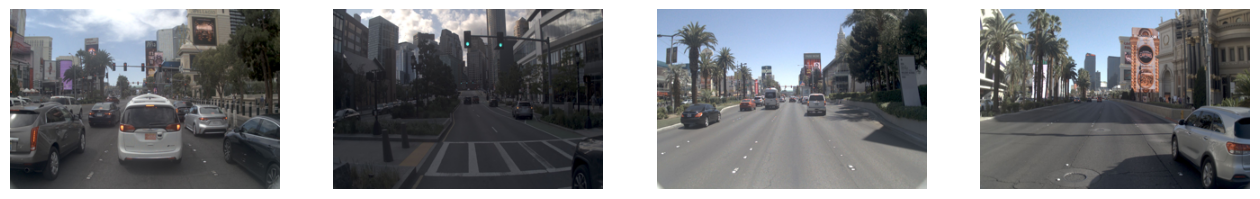

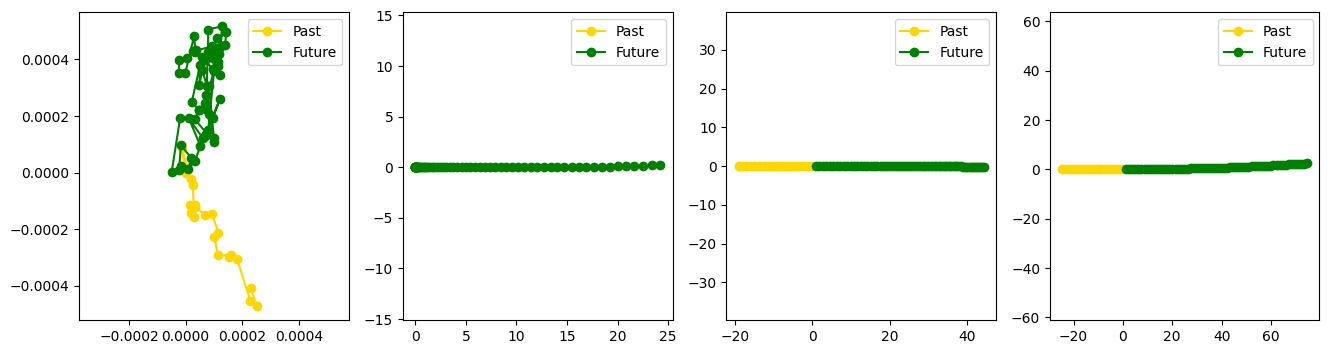

In [ ]:

import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
import os
k = 4
# load the data
data = []
test_files = os.listdir("val_real")

for i in range(k):
    with open(f"val_real/{test_files[i]}", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now let's train the model with synthetic data and test it with the real-world data.

In [ ]:
import torch
from torch.utils.data import Dataset
import pickle

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False):
        self.samples = file_list
        self.test = test

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Load pickle file
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        # Convert numpy arrays to tensors
        camera = torch.FloatTensor(data['camera']).permute(2, 0, 1)
        history = torch.FloatTensor(data['sdc_history_feature'])
        if not self.test:
          future = torch.FloatTensor(data['sdc_future_feature'])
          return {
            'camera': camera,
            'history': history,
            'future': future
          }
        else:
          return {
            'camera': camera,
            'history': history
          }



In [ ]:
class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        pass

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        prefix = f"[Step {step}] " if step is not None else ""
        metric_str = " | ".join(f"{k}: {v}" for k, v in metrics.items())
        # print(prefix + metric_str)

Note: Replace with your own planner below

In [ ]:
import torch
import torch.nn as nn

import torch
import torch.nn as nn

class DrivingPlanner(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN for processing camera images
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        # MLP for processing history features
        self.history_encoder = nn.Sequential(
            nn.Linear(21 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU()
        )

        # Decoder for predicting future trajectory
        self.decoder = nn.Sequential(
            nn.Linear(512, 512),  # 128 (CNN) + 128 (history)
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 60 * 3)  # Predict 60 timesteps of [x, y, heading]
        )

    def forward(self, camera, history):
        # Process camera images
        visual_features = self.cnn(camera)

        # Process history
        history_flat = history.reshape(history.size(0), -1)
        history_features = self.history_encoder(history_flat)

        # Combine features
        combined = torch.cat([visual_features, history_features], dim=1)

        # Predict future trajectory
        future = self.decoder(combined)
        future = future.reshape(-1, 60, 3)  # Reshape to (batch_size, timesteps, features)

        return future

In [ ]:
def train(model, train_loader, val_loader, optimizer, logger, num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            future = batch['future'].to(device)

            optimizer.zero_grad()
            pred_future = model(camera, history)
            loss = criterion(pred_future[..., :2], future[..., :2])
            loss.backward()
            optimizer.step()

            if idx % 10 == 0:
                logger.log(step=epoch * len(train_loader) + idx, loss=loss.item())
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, ade_all, fde_all = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                history = batch['history'].to(device)
                future = batch['future'].to(device)

                pred_future = model(camera, history)
                loss = criterion(pred_future, future)
                ADE = torch.norm(pred_future[:, :, :2] - future[:, :, :2], p=2, dim=-1).mean()
                FDE = torch.norm(pred_future[:, -1, :2] - future[:, -1, :2], p=2, dim=-1).mean()
                ade_all.append(ADE.item())
                fde_all.append(FDE.item())
                val_loss += loss.item()

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | ADE: {np.mean(ade_all):.4f} | FDE: {np.mean(fde_all):.4f}')

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
real_data_dir = "val_real"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
test_files = [os.path.join(real_data_dir, f) for f in os.listdir(real_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files)
val_dataset = DrivingDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

model = DrivingPlanner()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

logger = Logger()

train(model, train_loader, val_loader, optimizer, logger, num_epochs=50)


Epoch 1/50 | Train Loss: 34.2196 | Val Loss: 24.6224 | ADE: 4.6820 | FDE: 10.4576
Epoch 2/50 | Train Loss: 14.1429 | Val Loss: 13.0231 | ADE: 2.7882 | FDE: 6.8292
Epoch 3/50 | Train Loss: 10.3543 | Val Loss: 11.7449 | ADE: 2.2630 | FDE: 5.9745
Epoch 4/50 | Train Loss: 9.5784 | Val Loss: 12.1718 | ADE: 2.8946 | FDE: 7.4300
Epoch 5/50 | Train Loss: 9.8051 | Val Loss: 11.7242 | ADE: 2.5913 | FDE: 6.7289
Epoch 6/50 | Train Loss: 9.1120 | Val Loss: 11.2123 | ADE: 2.5504 | FDE: 6.5606
Epoch 7/50 | Train Loss: 9.1146 | Val Loss: 11.4665 | ADE: 2.6825 | FDE: 6.8201
Epoch 8/50 | Train Loss: 8.2373 | Val Loss: 11.0962 | ADE: 2.1964 | FDE: 6.0236
Epoch 9/50 | Train Loss: 7.9883 | Val Loss: 13.4661 | ADE: 2.7656 | FDE: 7.0221
Epoch 10/50 | Train Loss: 7.6934 | Val Loss: 10.3012 | ADE: 2.0581 | FDE: 5.7050
Epoch 11/50 | Train Loss: 7.4528 | Val Loss: 11.9493 | ADE: 3.2804 | FDE: 7.5974
Epoch 12/50 | Train Loss: 6.9219 | Val Loss: 9.2874 | ADE: 2.0043 | FDE: 5.7100
Epoch 13/50 | Train Loss: 6.9098 |

KeyboardInterrupt: 

We see a hugh sim-to-real gap here! Although the planner works well with synthetic sensors, it cannot generalize to the real wolrd scenario.

How to generalize your planner to the real world? Let's expore a simple trick: data mixing. This time we mix part of the real data with the synthetic data to train the model.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
real_data_dir = "val_real"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
test_files = [os.path.join(real_data_dir, f) for f in os.listdir(real_data_dir) if f.endswith('.pkl')]

train_files_mixed = train_files + test_files[:500]
test_files = test_files[500:]

train_dataset = DrivingDataset(train_files_mixed)
val_dataset = DrivingDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

model = DrivingPlanner()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

logger = Logger()

train(model, train_loader, val_loader, optimizer, logger, num_epochs=50)

Epoch 1/50 | Train Loss: 41.4737 | Val Loss: 20.0403 | ADE: 4.3582 | FDE: 10.2189
Epoch 2/50 | Train Loss: 13.0187 | Val Loss: 12.4083 | ADE: 2.3824 | FDE: 6.3498
Epoch 3/50 | Train Loss: 10.5500 | Val Loss: 11.5077 | ADE: 2.1975 | FDE: 6.0827
Epoch 4/50 | Train Loss: 9.3271 | Val Loss: 10.8815 | ADE: 2.0676 | FDE: 5.8145
Epoch 5/50 | Train Loss: 9.3257 | Val Loss: 12.4063 | ADE: 2.4282 | FDE: 6.3112
Epoch 6/50 | Train Loss: 9.4071 | Val Loss: 10.6630 | ADE: 2.3655 | FDE: 6.3930
Epoch 7/50 | Train Loss: 8.8644 | Val Loss: 10.2546 | ADE: 2.0699 | FDE: 5.7116
Epoch 8/50 | Train Loss: 8.6061 | Val Loss: 11.4252 | ADE: 2.4804 | FDE: 6.1663
Epoch 9/50 | Train Loss: 8.6863 | Val Loss: 9.9678 | ADE: 2.2974 | FDE: 6.1005
Epoch 10/50 | Train Loss: 7.7979 | Val Loss: 9.4721 | ADE: 2.3567 | FDE: 6.0009
Epoch 11/50 | Train Loss: 7.6442 | Val Loss: 8.9759 | ADE: 2.0043 | FDE: 5.4530
Epoch 12/50 | Train Loss: 7.1640 | Val Loss: 10.0405 | ADE: 2.3324 | FDE: 6.0469
Epoch 13/50 | Train Loss: 7.2473 | V

Finally, generate your submission.

In [ ]:
import pandas as pd
test_data_dir = "test_public_real"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model.eval()
all_plans = []
device = 'cuda'
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future = model(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase3.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
